In [166]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import roc_curve
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
import shap
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


WEEK1

DATA LOAD

In [167]:
df_raw = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv") # 원본 데이터
df_eda = df_raw.copy() #exploratory data analysis용 데이터
df_model  = df_raw.copy() # modeling 용 데이터

In [168]:
df_raw.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [169]:
df_raw .shape
df_raw.info()
df_raw.describe()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [170]:
df_raw.dtypes

customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges            str
Churn                   str
dtype: object

EDA (preprocessing)

In [171]:
df_eda.drop("customerID", axis=1, inplace=True) #customerID 제거
df_eda["SeniorCitizen"] = df_eda["SeniorCitizen"].map({0: "No", 1: "Yes"}) # SeniorCitizen를 숫자에서 범주형으로 변환

In [172]:
df_eda["TotalCharges"] = pd.to_numeric(df_eda["TotalCharges"], errors="coerce") # TotalCharges 숫자형 변환
df_eda["TotalCharges"] = df_eda["TotalCharges"].fillna(df_eda["TotalCharges"].median()) # TotalCharges 결측값 중앙값으로 대체

In [173]:
numeric_cols = df_eda.select_dtypes(include=["int64", "float64"]).columns # 숫자형 열 선택
categorical_cols = df_eda.select_dtypes(include=["object", "string", "category", "bool"]).columns # 범주형 열 선택

In [174]:
print("df_eda shape:", df_eda.shape)
df_eda.info()
df_eda.isnull().sum()

df_eda shape: (7043, 20)
<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   str    
 1   SeniorCitizen     7043 non-null   str    
 2   Partner           7043 non-null   str    
 3   Dependents        7043 non-null   str    
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   str    
 6   MultipleLines     7043 non-null   str    
 7   InternetService   7043 non-null   str    
 8   OnlineSecurity    7043 non-null   str    
 9   OnlineBackup      7043 non-null   str    
 10  DeviceProtection  7043 non-null   str    
 11  TechSupport       7043 non-null   str    
 12  StreamingTV       7043 non-null   str    
 13  StreamingMovies   7043 non-null   str    
 14  Contract          7043 non-null   str    
 15  PaperlessBilling  7043 non-null   str    
 16  PaymentMethod     7043 non-n

gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

EDA

In [175]:
print("Numeric columns:")
print(numeric_cols)
print("Categorical columns:")
print(categorical_cols)

Numeric columns:
Index(['tenure', 'MonthlyCharges', 'TotalCharges'], dtype='str')
Categorical columns:
Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService',
       'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
       'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
       'Contract', 'PaperlessBilling', 'PaymentMethod', 'Churn'],
      dtype='str')


In [176]:
print("Churn counts:")
print(df_eda["Churn"].value_counts())
print("Churn ratio:")
print(df_eda["Churn"].value_counts(normalize=True)) #imbalance

Churn counts:
Churn
No     5174
Yes    1869
Name: count, dtype: int64
Churn ratio:
Churn
No     0.73463
Yes    0.26537
Name: proportion, dtype: float64


Approximately 26.6% of customers have churned, indicating a moderate class imbalance in the dataset.

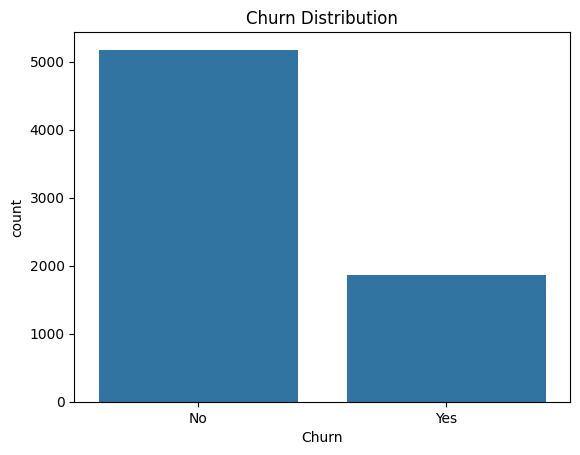

In [177]:
sns.countplot(x="Churn", data=df_eda)
plt.title("Churn Distribution")
plt.show()                                  

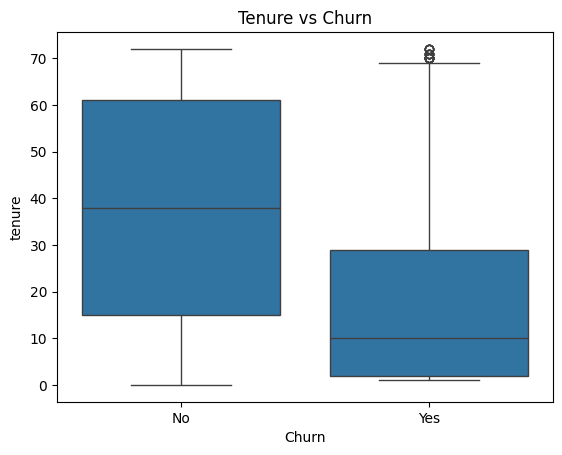

In [178]:
sns.boxplot(x="Churn", y="tenure", data=df_eda)
plt.title("Tenure vs Churn")
plt.show()

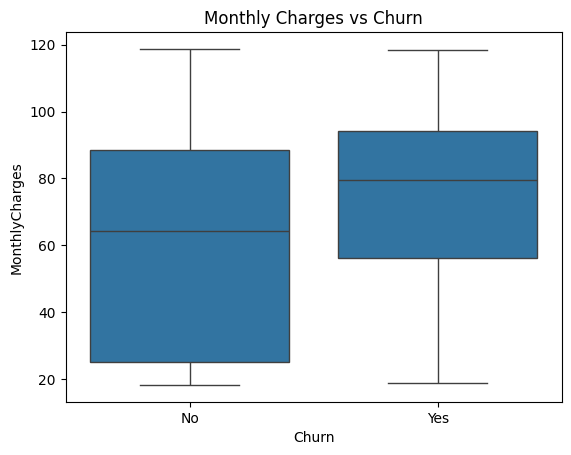

In [179]:
sns.boxplot(x="Churn", y="MonthlyCharges", data=df_eda)
plt.title("Monthly Charges vs Churn")
plt.show()

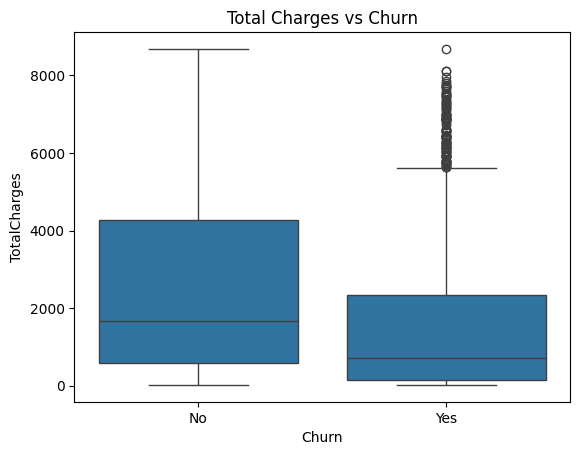

In [180]:
sns.boxplot(x="Churn", y="TotalCharges", data=df_eda)
plt.title("Total Charges vs Churn")
plt.show()

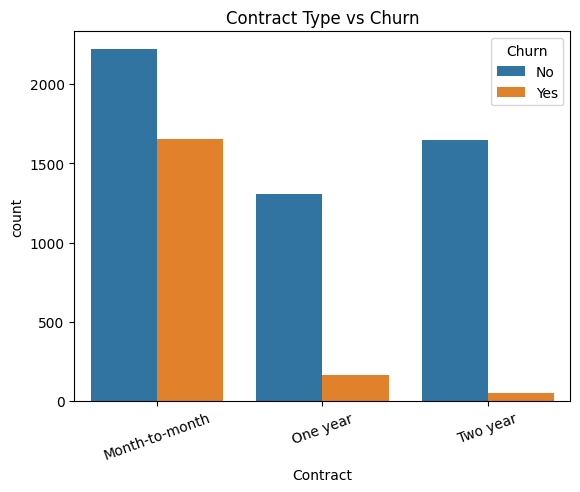

In [181]:
sns.countplot(x="Contract", hue="Churn", data=df_eda)
plt.xticks(rotation=20)
plt.title("Contract Type vs Churn")
plt.show()

In [182]:
df_eda.groupby("Contract")["Churn"].value_counts(normalize=True)

Contract        Churn
Month-to-month  No       0.572903
                Yes      0.427097
One year        No       0.887305
                Yes      0.112695
Two year        No       0.971681
                Yes      0.028319
Name: proportion, dtype: float64

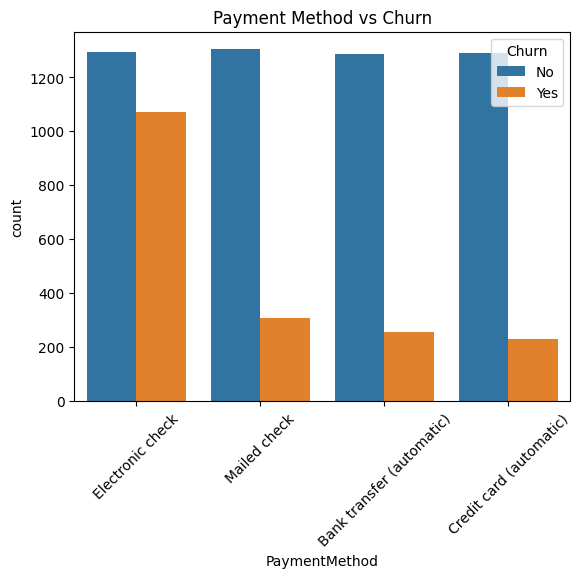

In [183]:
sns.countplot(x="PaymentMethod", hue="Churn", data=df_eda)
plt.xticks(rotation=45)
plt.title("Payment Method vs Churn")
plt.show()

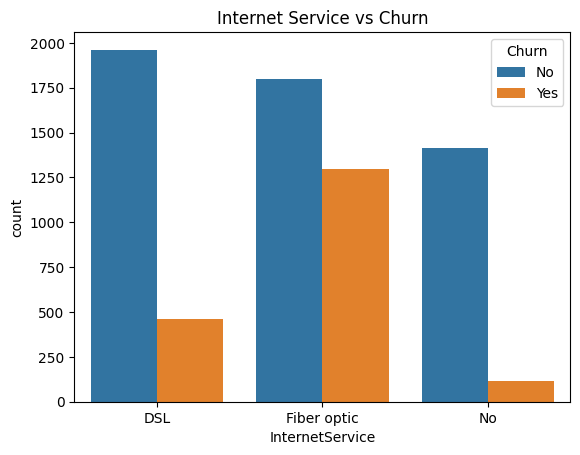

In [184]:
sns.countplot(x="InternetService", hue="Churn", data=df_eda)
plt.title("Internet Service vs Churn")
plt.show()

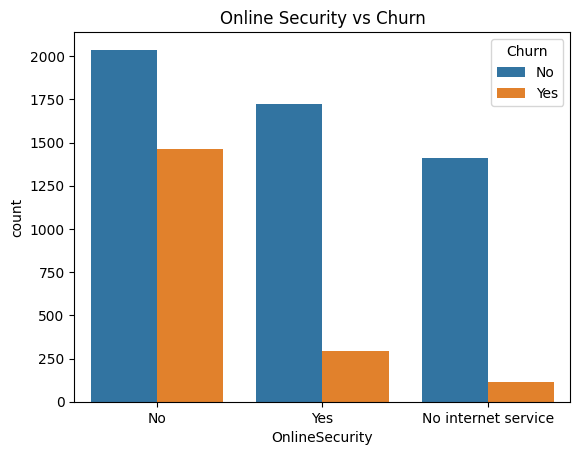

In [185]:
sns.countplot(x="OnlineSecurity", hue="Churn", data=df_eda)
plt.title("Online Security vs Churn")
plt.show()

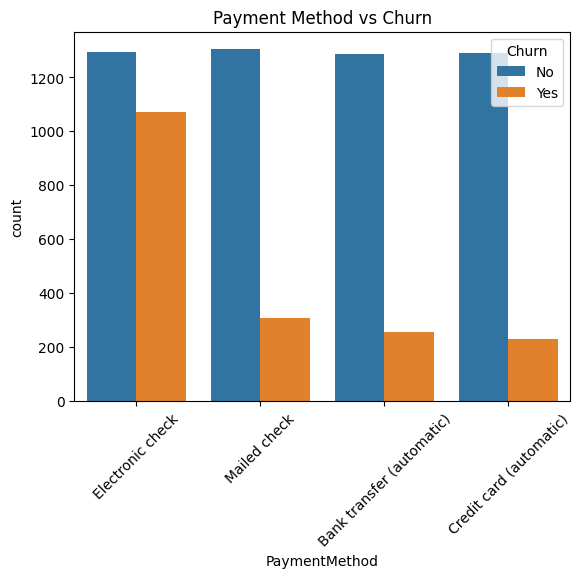

In [186]:
sns.countplot(x="PaymentMethod", hue="Churn", data=df_eda)
plt.xticks(rotation=45)
plt.title("Payment Method vs Churn")
plt.show()

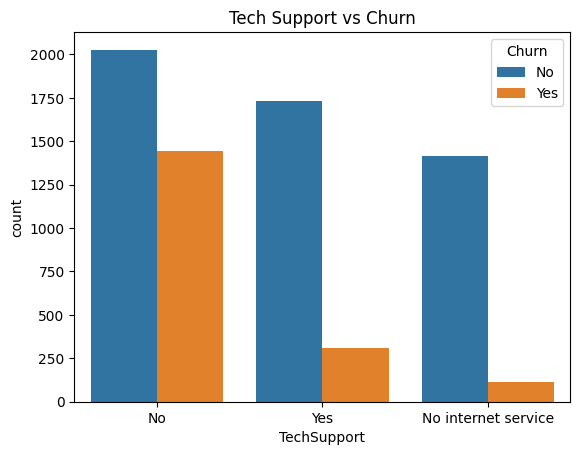

In [187]:
sns.countplot(x="TechSupport", hue="Churn", data=df_eda)
plt.title("Tech Support vs Churn")
plt.show()

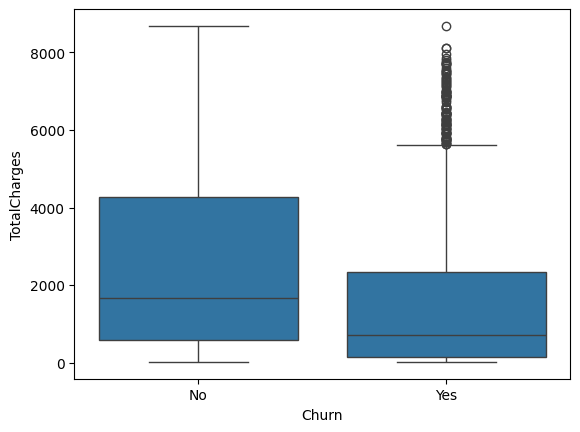

In [188]:
#Charges vs Churn Boxplot
sns.boxplot(x="Churn", y="TotalCharges", data=df_eda)
plt.show()

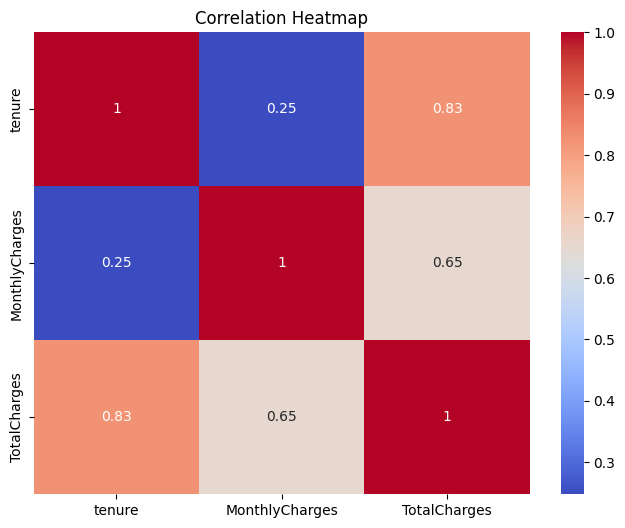

In [189]:
numeric_df_eda = df_eda.select_dtypes(include=["int64", "float64"])
plt.figure(figsize=(8, 6))
sns.heatmap(numeric_df_eda.corr(), cmap="coolwarm", annot=True)
plt.title("Correlation Heatmap")
plt.show()

Key Insights

Customers with shorter tenure are more likely to churn.

Higher monthly charges are associated with slightly higher churn rates.

Month-to-month contracts exhibit significantly higher churn compared to long-term contracts.

Customers with fiber optic internet service tend to churn more frequently.

Electronic check payment method shows higher churn rates.

Modeling preprocessing (FE 안된변수 기준)

In [190]:
df_model.drop("customerID", axis=1, inplace=True)

In [191]:
df_model["SeniorCitizen"] = df_model["SeniorCitizen"].map({0: "No", 1: "Yes"})

In [192]:
df_model["TotalCharges"] = pd.to_numeric(df_model["TotalCharges"], errors="coerce")

In [193]:
df_model["TotalCharges"] = df_model["TotalCharges"].fillna(df_model["TotalCharges"].median())

In [194]:
df_model["Churn"] = df_model["Churn"].map({"No": 0, "Yes": 1})

In [195]:
df_model = pd.get_dummies(df_model, drop_first=True)

In [196]:
print(df_model.shape)
df_model.info()

(7043, 31)
<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 31 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   tenure                                 7043 non-null   int64  
 1   MonthlyCharges                         7043 non-null   float64
 2   TotalCharges                           7043 non-null   float64
 3   Churn                                  7043 non-null   int64  
 4   gender_Male                            7043 non-null   bool   
 5   SeniorCitizen_Yes                      7043 non-null   bool   
 6   Partner_Yes                            7043 non-null   bool   
 7   Dependents_Yes                         7043 non-null   bool   
 8   PhoneService_Yes                       7043 non-null   bool   
 9   MultipleLines_No phone service         7043 non-null   bool   
 10  MultipleLines_Yes                      7043 non-null   bool   
 11  Inte

MODELING (logistic regression만)

In [197]:
X_base = df_model.drop("Churn", axis=1)
y_base = df_model["Churn"]

print("X shape:", X_base.shape)
print("y shape:", y_base.shape)

X shape: (7043, 30)
y shape: (7043,)


In [198]:
Xb_train, Xb_test, yb_train, yb_test = train_test_split(
    X_base, y_base,
    test_size=0.2,
    random_state=42,
    stratify=y_base
)

In [199]:
scaler_base = StandardScaler()

Xb_train = scaler_base.fit_transform(Xb_train)
Xb_test = scaler_base.transform(Xb_test)

logistic regression (baseline)

In [200]:
log_base = LogisticRegression(max_iter=2000)

log_base.fit(Xb_train, yb_train)

yb_pred = log_base.predict(Xb_test)
yb_prob = log_base.predict_proba(Xb_test)[:,1]

In [201]:
base_accuracy = accuracy_score(yb_test, yb_pred)
base_precision = precision_score(yb_test, yb_pred)
base_recall = recall_score(yb_test, yb_pred)
base_f1 = f1_score(yb_test, yb_pred)
base_auc = roc_auc_score(yb_test, yb_prob)

print("Baseline Logistic Performance")
print("Accuracy:", base_accuracy)
print("Precision:", base_precision)
print("Recall:", base_recall)
print("F1:", base_f1)
print("ROC-AUC:", base_auc)

Baseline Logistic Performance
Accuracy: 0.8069552874378992
Precision: 0.6583850931677019
Recall: 0.5668449197860963
F1: 0.6091954022988506
ROC-AUC: 0.8415846443979436


WEEK2

Feature engineering (로 8개의 변수 추가)

In [202]:
df_fe = df_raw.copy()


In [203]:
df_fe.drop("customerID", axis=1, inplace=True)

In [204]:
# SeniorCitizen categorical
df_fe["SeniorCitizen"] = df_fe["SeniorCitizen"].map({0: "No", 1: "Yes"})

# TotalCharges numeric
df_fe["TotalCharges"] = pd.to_numeric(df_fe["TotalCharges"], errors="coerce")
df_fe["TotalCharges"] = df_fe["TotalCharges"].fillna(df_fe["TotalCharges"].median())

# target
df_fe["Churn"] = df_fe["Churn"].map({"No":0,"Yes":1})

In [205]:
df_fe["tenure_group"] = pd.cut(
    df_fe["tenure"],
    bins=[0,12,24,48,72],
    labels=["0-12","12-24","24-48","48+"]
)   #tenure는 고객 충성도의 proxy, 그룹화하여 churn 패턴 더 잘 포착, 고객 유지 기간을 구간으로 나누면 churn 패턴이 잘 보임. 
    #신규 고객 churn 높음, 장기 고객 churn 낮음


In [206]:
df_fe["avg_monthly_spend"] = df_fe["TotalCharges"] / (df_fe["tenure"] + 1)  #monthly charge만 보면 정보 부족, 실제 지출 패턴을 더 잘 설명

In [207]:
df_fe["contract_risk"] = np.where(
    df_fe["Contract"] == "Month-to-month",1,0
)   #월 단위 계약 고객 churn 높음

In [208]:
services = [
    "PhoneService",
    "MultipleLines",
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies"
]

df_fe["service_count"] = (df_fe[services] == "Yes").sum(axis=1) #서비스 많을수록 churn 낮음

In [209]:
df_fe["long_term_customer"] = np.where(
    df_fe["tenure"] > 24, 1, 0  #장기 고객 여부
)

In [210]:
df_fe["high_monthly_charge"] = np.where(
    df_fe["MonthlyCharges"] > df_fe["MonthlyCharges"].median(), #요금 높은 고객 churn 높음
    1,0
)

In [211]:
df_fe["no_security"] = np.where(
    df_fe["OnlineSecurity"] == "No",1,0 #보안 서비스 없는 고객 churn 높음
)

In [212]:
df_fe["auto_payment"] = np.where(
    df_fe["PaymentMethod"].str.contains("automatic"),1,0    #자동 결제 고객 churn 낮음
)

Encoding

In [213]:
df_fe = pd.get_dummies(df_fe, drop_first=True)

Modeling (FE한걸로)

In [214]:
X = df_fe.drop("Churn", axis=1)
y = df_fe["Churn"]

Train Test Split

In [215]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42, 
    stratify=y
)

print(X_train.shape, X_test.shape)

(5634, 40) (1409, 40)


In [216]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

Modeling - Logistic regression(FE)

In [217]:
log_model = LogisticRegression(max_iter=2000)

log_model.fit(X_train, y_train)

y_pred_log = log_model.predict(X_test)
y_prob_log = log_model.predict_proba(X_test)[:,1]

Modeling - DecisionTree

In [218]:
tree_model = DecisionTreeClassifier(
    max_depth=5,
    random_state=42
)

tree_model.fit(X_train, y_train)

y_pred_tree = tree_model.predict(X_test)
y_prob_tree = tree_model.predict_proba(X_test)[:,1]

Metrics - logistic regression(FE)

In [219]:
log_accuracy = accuracy_score(y_test, y_pred_log)
log_precision = precision_score(y_test, y_pred_log)
log_recall = recall_score(y_test, y_pred_log)
log_f1 = f1_score(y_test, y_pred_log)
log_auc = roc_auc_score(y_test, y_prob_log)

Metrics - DecisionTree

In [220]:
tree_accuracy = accuracy_score(y_test, y_pred_tree)
tree_precision = precision_score(y_test, y_pred_tree)
tree_recall = recall_score(y_test, y_pred_tree)
tree_f1 = f1_score(y_test, y_pred_tree)
tree_auc = roc_auc_score(y_test, y_prob_tree)

In [221]:
results = pd.DataFrame({
    "Model":["Logistic Regression(FE)","Decision Tree"],
    "Accuracy":[log_accuracy, tree_accuracy],
    "Precision":[log_precision, tree_precision],
    "Recall":[log_recall, tree_recall],
    "F1":[log_f1, tree_f1],
    "AUC":[log_auc, tree_auc]
})

results

,Model,Accuracy,Precision,Recall,F1,AUC
0,Logistic Regression(FE),0.804826,0.667797,0.526738,0.588939,0.846064
1,Decision Tree,0.799148,0.631884,0.582888,0.606398,0.831322


ROC curve (Logistic regression VS DecisionTree)

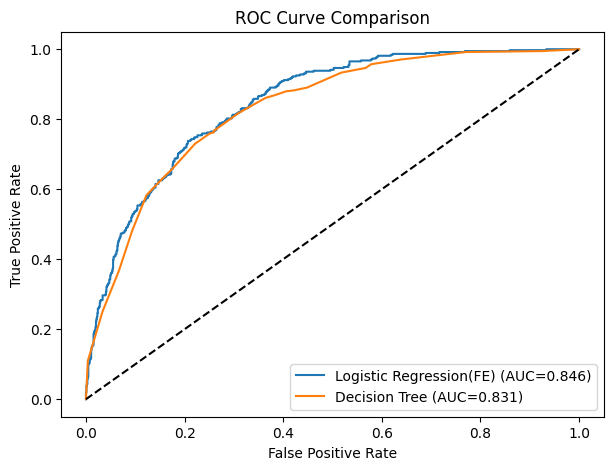

In [222]:
fpr_log, tpr_log, _ = roc_curve(y_test, y_prob_log)
fpr_tree, tpr_tree, _ = roc_curve(y_test, y_prob_tree)

plt.figure(figsize=(7,5))

plt.plot(fpr_log, tpr_log, label=f"Logistic Regression(FE) (AUC={log_auc:.3f})")
plt.plot(fpr_tree, tpr_tree, label=f"Decision Tree (AUC={tree_auc:.3f})")

plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()

plt.show()

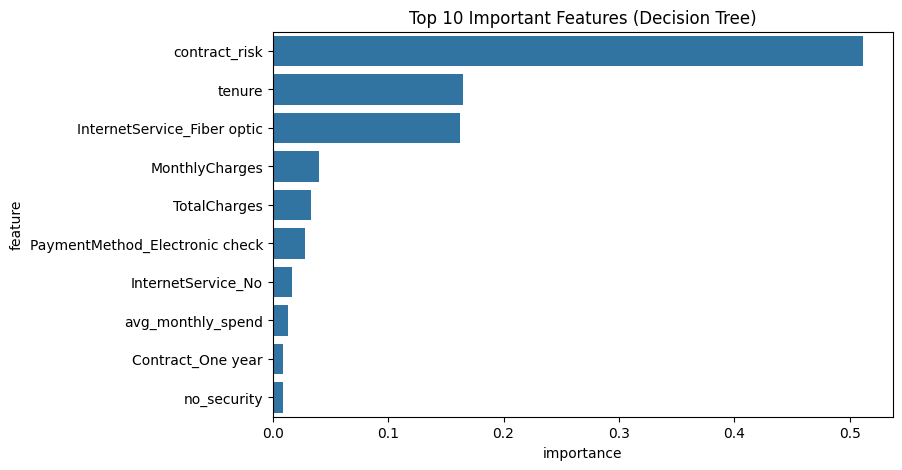

In [223]:
# =========================
# Feature Importance
# =========================

importances = tree_model.feature_importances_

feat_importance = pd.DataFrame({
    "feature": X.columns,
    "importance": importances
})

feat_importance = feat_importance.sort_values("importance", ascending=False).head(10)

plt.figure(figsize=(8,5))

sns.barplot(
    x="importance",
    y="feature",
    data=feat_importance
)

plt.title("Top 10 Important Features (Decision Tree)")
plt.show()

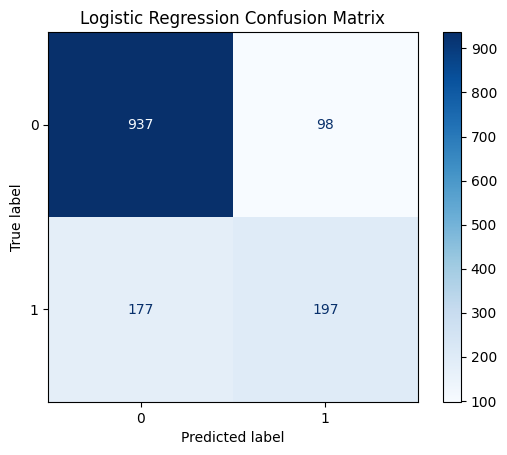

In [224]:
cm = confusion_matrix(y_test, y_pred_log)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)

disp.plot(cmap="Blues")

plt.title("Logistic Regression Confusion Matrix")
plt.show()

WEEk3

Modeling - random forest

In [225]:
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=8,
    min_samples_split=10,
    min_samples_leaf=4,
    random_state=42
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

In [226]:
rf_accuracy = accuracy_score(y_test, y_pred_rf)
rf_precision = precision_score(y_test, y_pred_rf)
rf_recall = recall_score(y_test, y_pred_rf)
rf_f1 = f1_score(y_test, y_pred_rf)
rf_auc = roc_auc_score(y_test, y_prob_rf)

Modeling - logistics(balanced)

In [227]:
log_model_bal = LogisticRegression(
    max_iter=5000,
    class_weight='balanced',
    solver='liblinear',
    random_state=42
)

log_model_bal.fit(X_train, y_train)

y_pred_log_bal = log_model_bal.predict(X_test)
y_prob_log_bal = log_model_bal.predict_proba(X_test)[:, 1]



In [228]:
log_bal_accuracy = accuracy_score(y_test, y_pred_log_bal)
log_bal_precision = precision_score(y_test, y_pred_log_bal)
log_bal_recall = recall_score(y_test, y_pred_log_bal)
log_bal_f1 = f1_score(y_test, y_pred_log_bal)
log_bal_auc = roc_auc_score(y_test, y_prob_log_bal)

Modeling - XG Boost

In [229]:

xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='logloss'
)

xgb_model.fit(X_train, y_train)

y_pred_xgb = xgb_model.predict(X_test)
y_prob_xgb = xgb_model.predict_proba(X_test)[:, 1]

In [230]:
xgb_accuracy = accuracy_score(y_test, y_pred_xgb)
xgb_precision = precision_score(y_test, y_pred_xgb)
xgb_recall = recall_score(y_test, y_pred_xgb)
xgb_f1 = f1_score(y_test, y_pred_xgb)
xgb_auc = roc_auc_score(y_test, y_prob_xgb)

Metrics result 

In [231]:
results = pd.DataFrame({
    "Model": [
        "Logistic (Baseline)",
        "Logistic (FE)",
        "Decision Tree",
        "Logistic (Balanced)",
        "Random Forest",
        "XGBoost"
    ],
    "Accuracy": [
        base_accuracy,
        log_accuracy,
        tree_accuracy,
        log_bal_accuracy,
        rf_accuracy,
        xgb_accuracy
    ],
    "Precision": [
        base_precision,
        log_precision,
        tree_precision,
        log_bal_precision,
        rf_precision,
        xgb_precision
    ],
    "Recall": [
        base_recall,
        log_recall,
        tree_recall,
        log_bal_recall,
        rf_recall,
        xgb_recall
    ],
    "F1": [
        base_f1,
        log_f1,
        tree_f1,
        log_bal_f1,
        rf_f1,
        xgb_f1
    ],
    "AUC": [
        base_auc,
        log_auc,
        tree_auc,
        log_bal_auc,
        rf_auc,
        xgb_auc
    ]
})

results.sort_values("AUC", ascending=False)

,Model,Accuracy,Precision,Recall,F1,AUC
1,Logistic (FE),0.804826,0.667797,0.526738,0.588939,0.846064
5,XGBoost,0.805536,0.668919,0.529412,0.591045,0.845917
3,Logistic (Balanced),0.738822,0.505137,0.788770,0.615866,0.845754
4,Random Forest,0.804116,0.668966,0.518717,0.584337,0.843788
0,Logistic (Baseline),0.806955,0.658385,0.566845,0.609195,0.841585
2,Decision Tree,0.799148,0.631884,0.582888,0.606398,0.831322


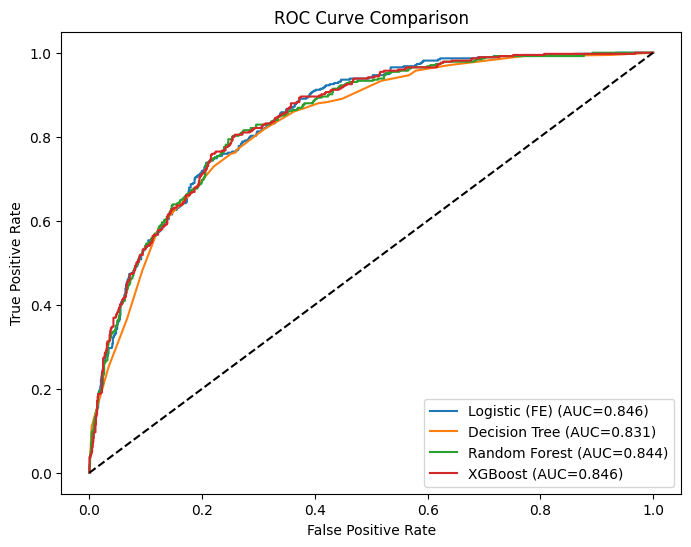

In [232]:
fpr_log, tpr_log, _ = roc_curve(y_test, y_prob_log) #핵심 네개
fpr_tree, tpr_tree, _ = roc_curve(y_test, y_prob_tree)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_prob_xgb)

plt.figure(figsize=(8,6))

plt.plot(fpr_log, tpr_log, label="Logistic (FE) (AUC=" + str(round(log_auc, 3)) + ")")
plt.plot(fpr_tree, tpr_tree, label="Decision Tree (AUC=" + str(round(tree_auc, 3)) + ")")
plt.plot(fpr_rf, tpr_rf, label="Random Forest (AUC=" + str(round(rf_auc, 3)) + ")")
plt.plot(fpr_xgb, tpr_xgb, label="XGBoost (AUC=" + str(round(xgb_auc, 3)) + ")")

plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")

plt.legend()
plt.show()

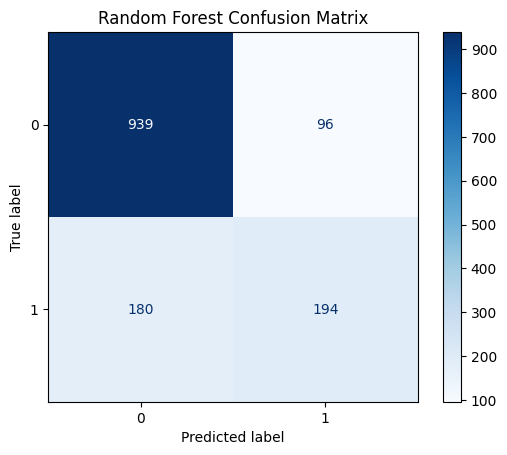

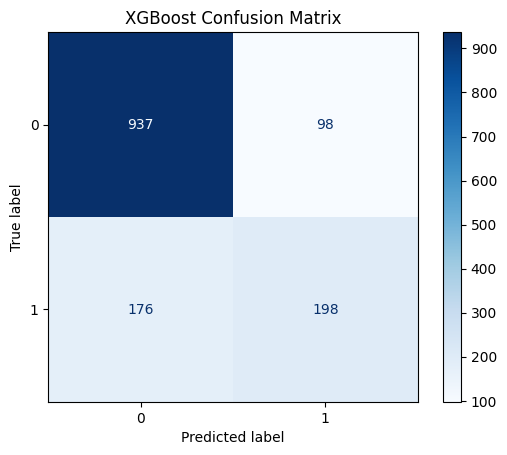

In [233]:
# Random Forest
cm_rf = confusion_matrix(y_test, y_pred_rf)
disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf)
disp_rf.plot(cmap="Blues")
plt.title("Random Forest Confusion Matrix")
plt.show()

# XGBoost
cm_xgb = confusion_matrix(y_test, y_pred_xgb)
disp_xgb = ConfusionMatrixDisplay(confusion_matrix=cm_xgb)
disp_xgb.plot(cmap="Blues")
plt.title("XGBoost Confusion Matrix")
plt.show()

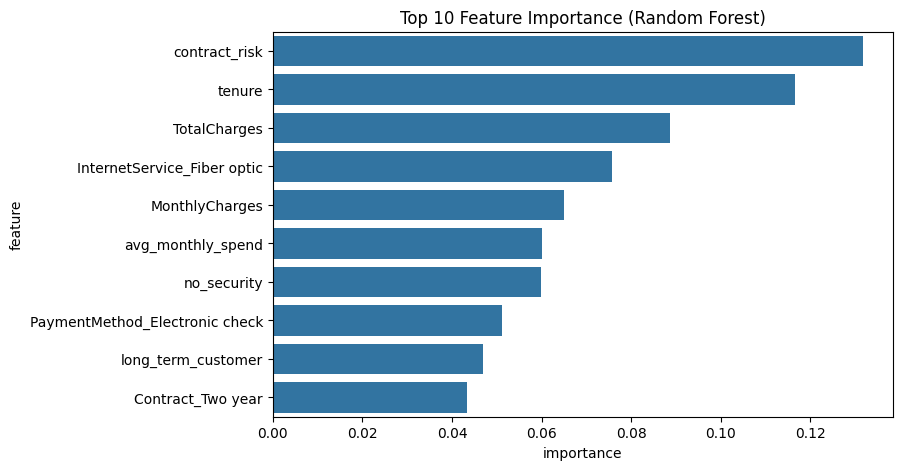

In [234]:
rf_importance = rf_model.feature_importances_ #랜덤 포레스트 모델에서 feature importance 추출

rf_feat = pd.DataFrame({
    "feature": X.columns,
    "importance": rf_importance
}).sort_values("importance", ascending=False).head(10)

plt.figure(figsize=(8,5))
sns.barplot(x="importance", y="feature", data=rf_feat)
plt.title("Top 10 Feature Importance (Random Forest)")
plt.show()

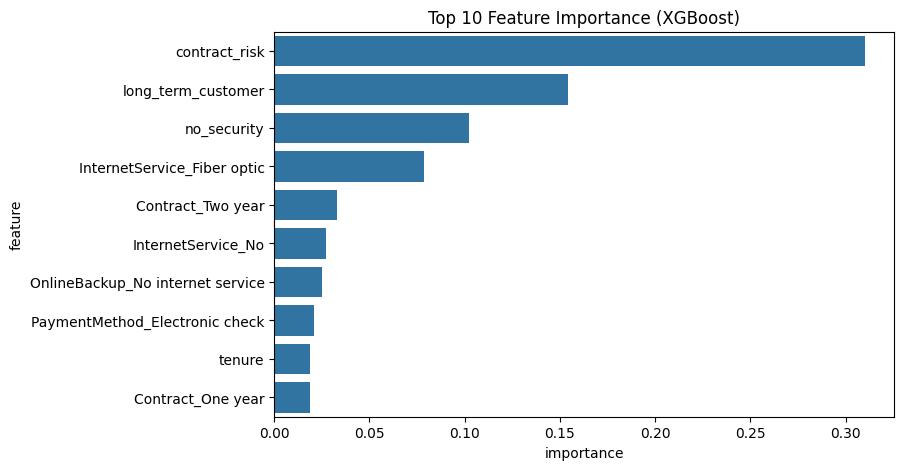

In [235]:
xgb_importance = xgb_model.feature_importances_ #XGBoost 모델에서 feature importance 추출

xgb_feat = pd.DataFrame({
    "feature": X.columns,
    "importance": xgb_importance
}).sort_values("importance", ascending=False).head(10)

plt.figure(figsize=(8,5))
sns.barplot(x="importance", y="feature", data=xgb_feat)
plt.title("Top 10 Feature Importance (XGBoost)")
plt.show()

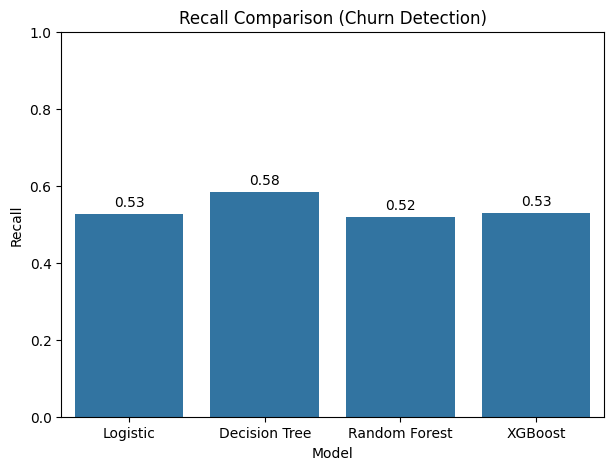

In [236]:
recall_df = pd.DataFrame({
    "Model": ["Logistic", "Decision Tree", "Random Forest", "XGBoost"],
    "Recall": [log_recall, tree_recall, rf_recall, xgb_recall]
})

plt.figure(figsize=(7,5))
sns.barplot(x="Model", y="Recall", data=recall_df)

plt.title("Recall Comparison (Churn Detection)")
plt.ylim(0,1)

for i, v in enumerate(recall_df["Recall"]):
    plt.text(i, v + 0.02, f"{v:.2f}", ha='center')

plt.show()

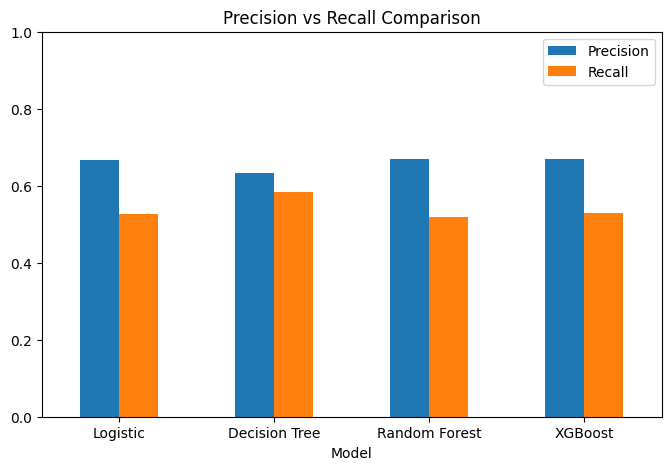

In [237]:
pr_df = pd.DataFrame({
    "Model": ["Logistic", "Decision Tree", "Random Forest", "XGBoost"],
    "Precision": [log_precision, tree_precision, rf_precision, xgb_precision],
    "Recall": [log_recall, tree_recall, rf_recall, xgb_recall]
})

pr_df.set_index("Model").plot(kind="bar", figsize=(8,5))

plt.title("Precision vs Recall Comparison")
plt.ylim(0,1)
plt.xticks(rotation=0)
plt.show()

In [238]:
rf_importance = pd.Series(rf_model.feature_importances_, index=X.columns).sort_values(ascending=False)
xgb_importance = pd.Series(xgb_model.feature_importances_, index=X.columns).sort_values(ascending=False)

print(rf_importance.head(10))
print(xgb_importance.head(10))

contract_risk                     0.131785
tenure                            0.116650
TotalCharges                      0.088662
InternetService_Fiber optic       0.075815
MonthlyCharges                    0.065086
avg_monthly_spend                 0.059993
no_security                       0.059756
PaymentMethod_Electronic check    0.051167
long_term_customer                0.047020
Contract_Two year                 0.043308
dtype: float64
contract_risk                       0.310110
long_term_customer                  0.154296
no_security                         0.102029
InternetService_Fiber optic         0.078710
Contract_Two year                   0.032881
InternetService_No                  0.026926
OnlineBackup_No internet service    0.025028
PaymentMethod_Electronic check      0.020968
tenure                              0.018725
Contract_One year                   0.018718
dtype: float32


In [239]:
explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test)

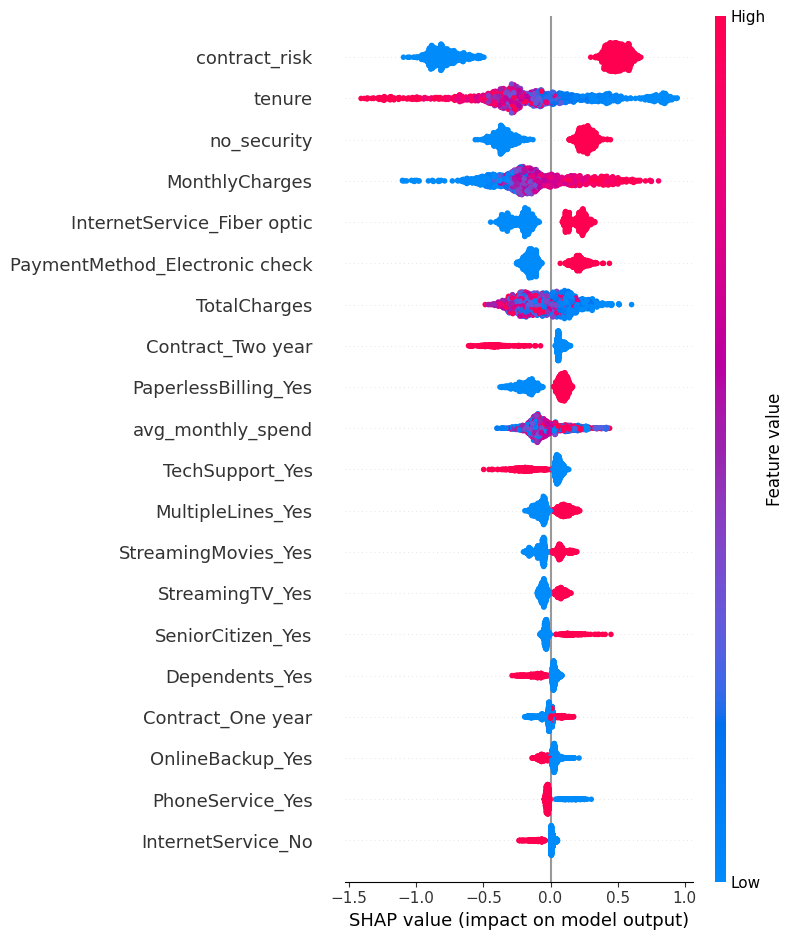

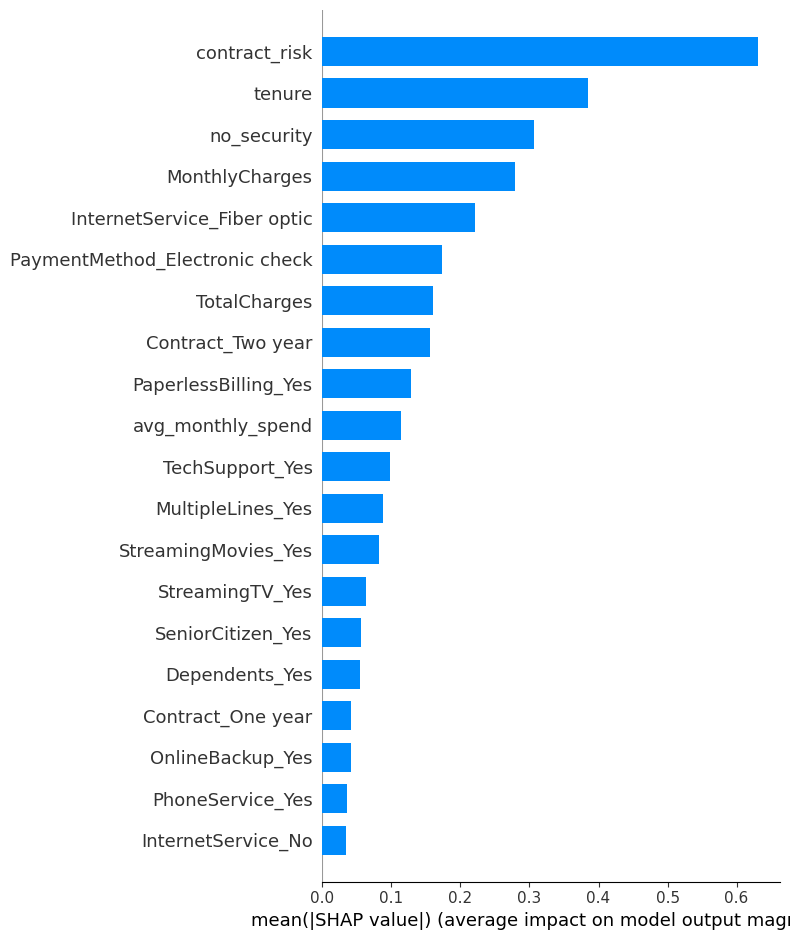

In [240]:
X_test_df = pd.DataFrame(X_test, columns=X.columns)

shap.summary_plot(shap_values, X_test_df)
shap.summary_plot(shap_values, X_test_df, plot_type="bar")

shap.initjs()
shap.force_plot(explainer.expected_value, shap_values[0], X_test_df.iloc[0])

In [241]:
y_pred = (y_prob_xgb > 0.5).astype(int)

In [242]:
thresholds = [0.3, 0.4, 0.5, 0.6]

for t in thresholds:
    y_pred = (y_prob_xgb > t).astype(int)
    
    print("Threshold:", t)
    print("Recall:", recall_score(y_test, y_pred))
    print("Precision:", precision_score(y_test, y_pred))
    print("-----")

Threshold: 0.3
Recall: 0.767379679144385
Precision: 0.5404896421845574
-----
Threshold: 0.4
Recall: 0.6550802139037433
Precision: 0.580568720379147
-----
Threshold: 0.5
Recall: 0.5294117647058824
Precision: 0.668918918918919
-----
Threshold: 0.6
Recall: 0.3850267379679144
Precision: 0.7309644670050761
-----


In [245]:

param_grid = {
    "max_depth": [3, 5, 7],
    "learning_rate": [0.01, 0.05, 0.1],
    "n_estimators": [100, 200, 300],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0]
}

grid = GridSearchCV(
    estimator=XGBClassifier(
        random_state=42,
        eval_metric="logloss"
    ),
    param_grid=param_grid,
    cv=3,
    scoring="roc_auc",
    n_jobs=-1
)

grid.fit(X_train, y_train)

best_xgb = grid.best_estimator_

print("Best Params:", grid.best_params_)
print("Best CV Score:", grid.best_score_)

Best Params: {'colsample_bytree': 0.8, 'learning_rate': 0.01, 'max_depth': 5, 'n_estimators': 300, 'subsample': 0.8}
Best CV Score: 0.8497612924400291


In [246]:
y_pred_best_xgb = best_xgb.predict(X_test)
y_prob_best_xgb = best_xgb.predict_proba(X_test)[:, 1]

best_xgb_accuracy = accuracy_score(y_test, y_pred_best_xgb)
best_xgb_precision = precision_score(y_test, y_pred_best_xgb)
best_xgb_recall = recall_score(y_test, y_pred_best_xgb)
best_xgb_f1 = f1_score(y_test, y_pred_best_xgb)
best_xgb_auc = roc_auc_score(y_test, y_prob_best_xgb)

print("Accuracy:", best_xgb_accuracy)
print("Precision:", best_xgb_precision)
print("Recall:", best_xgb_recall)
print("F1:", best_xgb_f1)
print("AUC:", best_xgb_auc)

Accuracy: 0.8005677785663591
Precision: 0.662020905923345
Recall: 0.5080213903743316
F1: 0.5748865355521936
AUC: 0.8469102792632204


In [247]:
threshold_results = []

for t in [0.3, 0.35, 0.4, 0.45, 0.5, 0.55]:
    y_pred_t = (y_prob_best_xgb > t).astype(int)

    threshold_results.append({
        "Threshold": t,
        "Precision": precision_score(y_test, y_pred_t),
        "Recall": recall_score(y_test, y_pred_t),
        "F1": f1_score(y_test, y_pred_t),
        "Accuracy": accuracy_score(y_test, y_pred_t)
    })

threshold_df = pd.DataFrame(threshold_results)
threshold_df

,Threshold,Precision,Recall,F1,Accuracy
0,0.30,0.543396,0.770053,0.637168,0.767211
1,0.35,0.574514,0.711230,0.635603,0.783534
2,0.40,0.597015,0.641711,0.618557,0.789922
3,0.45,0.626781,0.588235,0.606897,0.797729
4,0.50,0.662021,0.508021,0.574887,0.800568
5,0.55,0.698198,0.414439,0.520134,0.797019


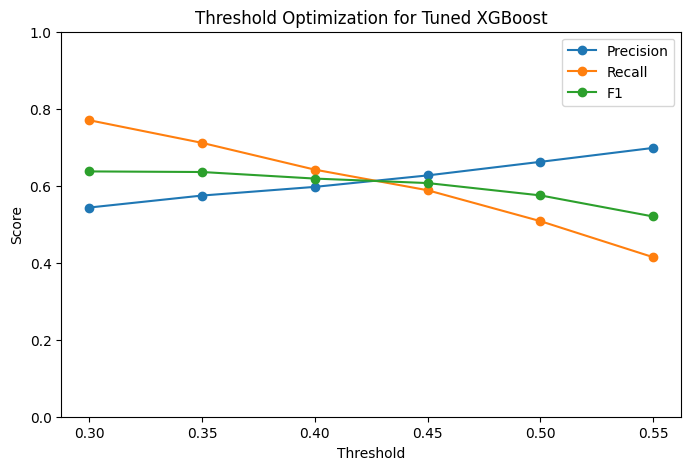

In [248]:
plt.figure(figsize=(8,5))
plt.plot(threshold_df["Threshold"], threshold_df["Precision"], marker="o", label="Precision")
plt.plot(threshold_df["Threshold"], threshold_df["Recall"], marker="o", label="Recall")
plt.plot(threshold_df["Threshold"], threshold_df["F1"], marker="o", label="F1")

plt.title("Threshold Optimization for Tuned XGBoost")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.legend()
plt.show()

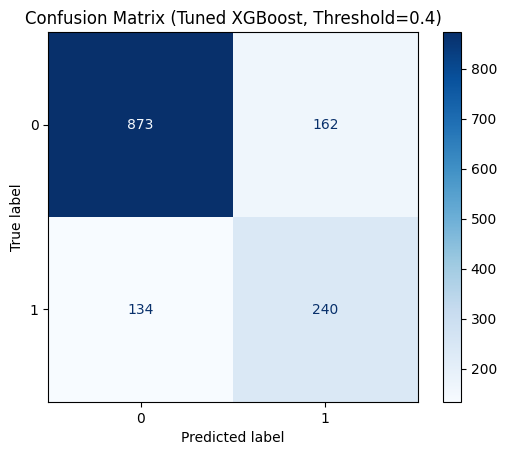

In [249]:
best_threshold = 0.4
y_pred_opt = (y_prob_best_xgb > best_threshold).astype(int)

cm_opt = confusion_matrix(y_test, y_pred_opt)
disp_opt = ConfusionMatrixDisplay(confusion_matrix=cm_opt)
disp_opt.plot(cmap="Blues")
plt.title("Confusion Matrix (Tuned XGBoost, Threshold=0.4)")
plt.show()